#MNIST dataset, simple fully connected neural network with 3 layers

Our objective is to set up a neural network problem using the MNIST dataset (https://www.tensorflow.org/datasets/catalog/mnist), which is commonly used for classifying handwritten digits. We'll implement a fully connected (FC) neural network and test three different combinations of activation functions, optimizers, regularizers, and loss functions.

Here's the plan for three different models:

Dataset MNIST provides input of size 28x28.

Let's use dense layers of size 128, 64 and 10 (3 layers) for all the 3 models.
1. Model 1: Basic Model
Activation Function: ReLU for hidden layers, Softmax for output
Optimizer: Stochastic Gradient Descent (SGD)
Regularizer: None
Loss Function: Categorical Crossentropy
2. Model 2: Intermediate Model
Activation Function: Leaky ReLU for hidden layers, Softmax for output
Optimizer: Adam
Regularizer: L2 regularization
Loss Function: Categorical Crossentropy
3. Model 3: Advanced Model
Activation Function: Swish for hidden layers, Softmax for output
Optimizer: Adam with learning rate decay
Regularizer: Dropout
Loss Function: Categorical Crossentropy

Steps:
Data Preparation: We'll load and preprocess the MNIST dataset.
Model Definition: Three models will be created with the configurations mentioned above.
Training: Train the models and track metrics like loss and accuracy.
Evaluation: Compare the performance of the three models

MNIST is a simple dataset. The expectation is that though all 3 models might produce a high accuracy, model 3 might perform better than model 2, and model 2 might perform better than model 1. (It need not be true all the time, due to the simple nature of this dataset)

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras import regularizers
import matplotlib.pyplot as plt

# Load dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.reshape(-1, 28*28) / 255.0
x_test = x_test.reshape(-1, 28*28) / 255.0

# Convert labels to categorical
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [2]:
def create_model_1():
    model = Sequential([
        Dense(128, activation='relu', input_shape=(28*28,)),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer=SGD(), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [3]:
def create_model_2():
    model = Sequential([
        Dense(128, activation='leaky_relu', input_shape=(28*28,), kernel_regularizer=regularizers.l2(0.001)),
        Dense(64, activation='leaky_relu', kernel_regularizer=regularizers.l2(0.001)),
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [4]:
def create_model_3():
    model = Sequential([
        Dense(128, activation='swish', input_shape=(28*28,)),
        Dropout(0.5),
        Dense(64, activation='swish'),
        Dropout(0.5),
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer=Adam(learning_rate=0.001, decay=1e-6), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

Model 1 (Basic Model):


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


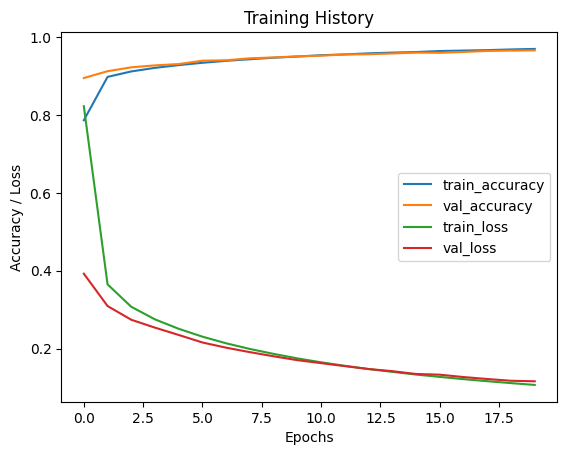

Test accuracy: 0.9665, Test loss: 0.1158

Model 2 (Intermediate Model):


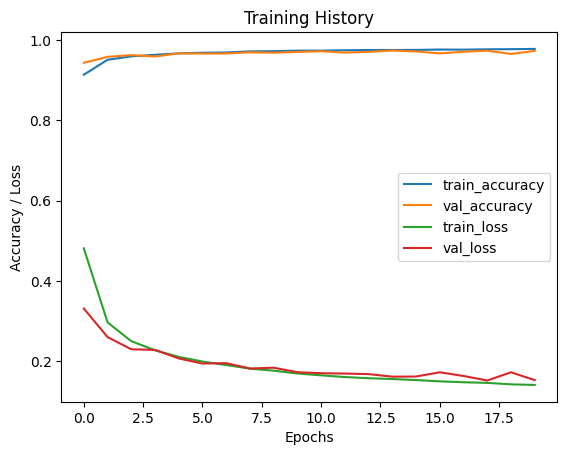

Test accuracy: 0.9734, Test loss: 0.1523

Model 3 (Advanced Model):


/usr/local/lib/python3.10/dist-packages/keras/src/optimizers/base_optimizer.py:33: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


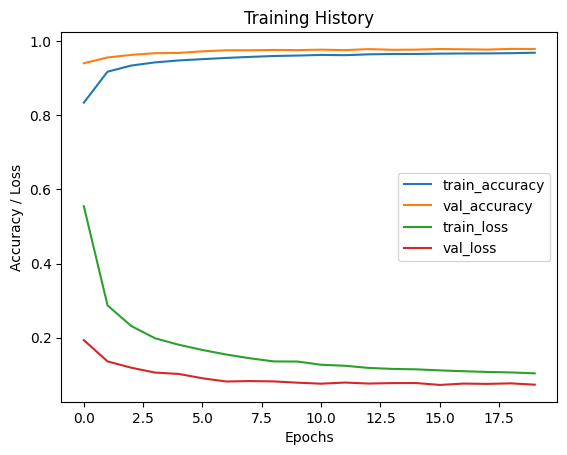

Test accuracy: 0.9793, Test loss: 0.0730


In [5]:
def train_and_plot(model, x_train, y_train, x_test, y_test, epochs=20, batch_size=64):
    history = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=epochs, batch_size=batch_size, verbose=0)

    # Plot the accuracy and loss
    plt.plot(history.history['accuracy'], label='train_accuracy')
    plt.plot(history.history['val_accuracy'], label='val_accuracy')
    plt.plot(history.history['loss'], label='train_loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.title('Training History')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy / Loss')
    plt.legend()
    plt.show()

    # Evaluate the model
    loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
    print(f"Test accuracy: {accuracy:.4f}, Test loss: {loss:.4f}")

# Train and plot for all models
print("Model 1 (Basic Model):")
model_1 = create_model_1()
train_and_plot(model_1, x_train, y_train, x_test, y_test)

print("\nModel 2 (Intermediate Model):")
model_2 = create_model_2()
train_and_plot(model_2, x_train, y_train, x_test, y_test)

print("\nModel 3 (Advanced Model):")
model_3 = create_model_3()
train_and_plot(model_3, x_train, y_train, x_test, y_test)

# CIFAR-10 with similar network

* When working with the MNIST dataset, the images are 28x28 grayscale images (i.e., single-channel). In a basic fully connected (FC) network, you flatten the 2D image (28x28) into a 1D vector of 784 elements before passing it to the dense layers.
* However, if we don't explicitly add the Flatten() layer in some frameworks (like TensorFlow), it may be inferred implicitly, especially for simple datasets like MNIST because the data is 2D (28x28). So, you might not have noticed the need for Flatten() in MNIST if it's handled automatically.



* In the case of CIFAR-10, the images are 32x32 with 3 color channels (RGB), meaning the shape of each image is (32, 32, 3). Before passing this 3D image to fully connected layers, you need to explicitly flatten the image into a 1D vector of 32*32*3 = 3,072 elements.

* If you don’t flatten the image in CIFAR-10, the fully connected layer won’t know how to process the multi-dimensional (3D) image data directly. Unlike in the MNIST case, it’s less likely that this will be inferred automatically.


So our first layer in this scenario can be tf.keras.layers.Flatten(input_shape=(32, 32, 3)). This can be followed by fully connected layers of size 512, 256 and 10 respectively

In [7]:
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import tensorflow as tf

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize the data to [0, 1] range
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Convert class labels to one-hot encoded vectors
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [8]:
def create_model_1():
    model = tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(32, 32, 3)),
        tf.keras.layers.Dense(512, activation='relu'),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [9]:
def create_model_2():
    model = tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(32, 32, 3)),
        tf.keras.layers.Dense(512, activation='leaky_relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        tf.keras.layers.Dense(256, activation='leaky_relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [10]:
def create_model_3():
    model = tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(32, 32, 3)),
        tf.keras.layers.Dense(512, activation='swish'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(256, activation='swish'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001, decay=1e-6),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

Model 1 (Basic Model):


/usr/local/lib/python3.10/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


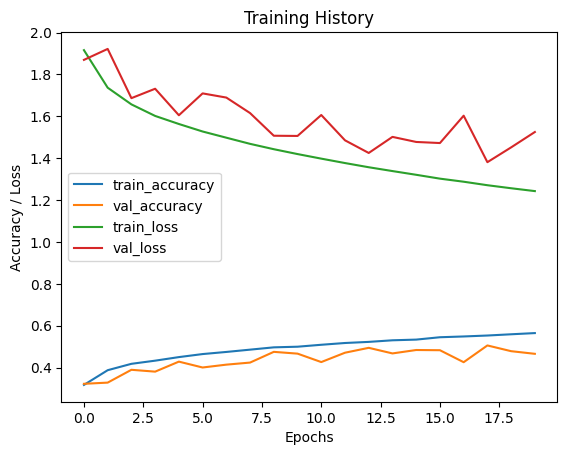

Test accuracy: 0.4660, Test loss: 1.5252

Model 2 (Intermediate Model):


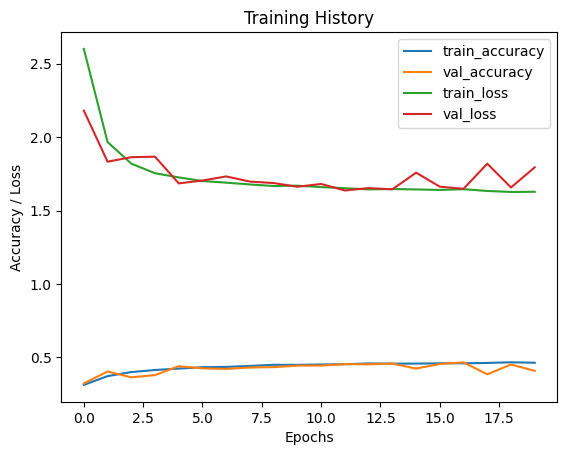

Test accuracy: 0.4089, Test loss: 1.7947

Model 3 (Advanced Model):


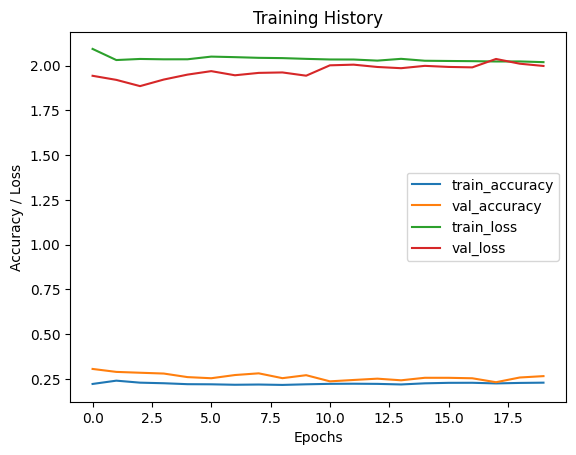

Test accuracy: 0.2661, Test loss: 1.9978


In [11]:
def train_and_plot(model, x_train, y_train, x_test, y_test, epochs=20, batch_size=64):
    history = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=epochs, batch_size=batch_size, verbose=0)

    # Plot accuracy and loss
    plt.plot(history.history['accuracy'], label='train_accuracy')
    plt.plot(history.history['val_accuracy'], label='val_accuracy')
    plt.plot(history.history['loss'], label='train_loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.title('Training History')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy / Loss')
    plt.legend()
    plt.show()

    # Evaluate the model
    loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
    print(f"Test accuracy: {accuracy:.4f}, Test loss: {loss:.4f}")

# Train and plot for all models
print("Model 1 (Basic Model):")
model_1 = create_model_1()
train_and_plot(model_1, x_train, y_train, x_test, y_test)

print("\nModel 2 (Intermediate Model):")
model_2 = create_model_2()
train_and_plot(model_2, x_train, y_train, x_test, y_test)

print("\nModel 3 (Advanced Model):")
model_3 = create_model_3()
train_and_plot(model_3, x_train, y_train, x_test, y_test)

What is your observation here?

Was this the anticipated observation?

Try reading up a little and try to identify potential reasons as to why this behaviour was exhibited.

## The lower accuracies you’re seeing for all three models in CIFAR-10 compared to MNIST can be attributed to several factors:

1. Complexity of the Dataset

CIFAR-10 is significantly more complex than MNIST. It consists of 32x32 color images (RGB channels), while MNIST consists of 28x28 grayscale images. CIFAR-10 images contain a lot more variability in terms of shapes, textures, and backgrounds, making it harder for simpler models like fully connected networks to achieve high accuracy without proper design.

2. Fully Connected Networks vs. Convolutional Networks

For image classification tasks, especially with more complex datasets like CIFAR-10, fully connected (FC) neural networks struggle because they don't capture the spatial structure of images. Convolutional Neural Networks (CNNs) are better suited for such tasks as they use convolutional layers to learn spatial hierarchies in images. FC networks treat all pixels independently, which causes a loss of spatial information (e.g., the relationship between adjacent pixels).

3. Overfitting and Regularization

In Model 3, you introduced dropout, which is a good way to prevent overfitting. However, if dropout is applied too heavily (e.g., 0.5 for both layers), it can cause underfitting in smaller models, especially with more complex data like CIFAR-10. This can result in the model not learning enough features from the training data, leading to poor generalization and lower accuracy on the test set.

4. Activation Functions

ReLU (used in Model 1) is a good general-purpose activation function, but it might not be enough by itself, especially in a fully connected network for CIFAR-10. ReLU is also prone to the dying ReLU problem, where neurons can output zero for most of the input, leading to reduced learning.
Leaky ReLU (Model 2) helps mitigate the dying ReLU issue, but the overall architecture still doesn't capture spatial features, leading to suboptimal performance.
Swish (used in Model 3) has been shown to perform better than ReLU in deeper architectures like CNNs, but in fully connected networks, it may not provide significant advantages without spatial feature extraction (e.g., via convolution).

5. Optimizer and Learning Rate

The Adam optimizer (used in Models 2 and 3) typically performs well on a wide range of problems, but its effectiveness is tied to the architecture of the network. When the model architecture isn’t suitable for the task (like in fully connected networks for image data), changing the optimizer alone won’t yield significant improvements. Furthermore, Adam with learning rate decay (Model 3) might not have had enough training time to properly adjust the learning rate.

6. Model Depth and Capacity

The models we designed have two fully connected layers (512 and 256 units), which may not have enough capacity to learn the complexities of CIFAR-10 images. Deeper networks or networks with more parameters can generally handle more complex datasets, but FC networks need significantly more capacity compared to CNNs.

## How to Improve Performance
To improve performance on CIFAR-10, here are some steps you could take:

1. Use Convolutional Neural Networks (CNNs):

CNNs are specifically designed for image data and capture spatial relationships between pixels, making them more suitable for image classification tasks. A basic CNN architecture for CIFAR-10 would include several convolutional layers followed by pooling layers before fully connected layers.

2. Increase Model Capacity:

If you want to stick with fully connected layers, consider increasing the depth and the number of neurons. This could improve the network's ability to handle the complexity of CIFAR-10, but this approach is computationally expensive and less efficient than using CNNs.

3. Data Augmentation:

To improve generalization, apply data augmentation to artificially increase the size of your dataset. Techniques such as random flips, rotations, and zooms help the model become invariant to such transformations and prevent overfitting.

4. Regularization and Dropout:

In Model 3, you applied dropout. Fine-tuning the dropout rate can help prevent underfitting. Additionally, combining dropout with L2 regularization may further improve performance.

5. Batch Normalization: (WILL BE COVERED IN NEXT SESSION)

Including batch normalization layers can help accelerate training and stabilize the learning process, especially for deeper networks.

# MISCELLANEOUS:

## Can you implement a model which solves any issue(s) you encountered here?

### CNN Model Definition

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator

def create_cnn_model():
    model = Sequential([
        # 1st Convolutional Layer
        Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.2),

        # 2nd Convolutional Layer
        Conv2D(64, (3, 3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.3),

        # 3rd Convolutional Layer
        Conv2D(128, (3, 3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.4),

        # Flatten the output of the convolutional layers
        Flatten(),

        # Fully connected layer
        Dense(512, activation='relu'),
        Dropout(0.5),

        # Output layer with 10 classes
        Dense(10, activation='softmax')
    ])

    # Compile the model with Adam optimizer and categorical crossentropy loss
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    return model

### Data Augmentation

In [13]:
# Create an ImageDataGenerator for data augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

# Fit the generator to the training data
datagen.fit(x_train)

### Training the Model

In [14]:
# Create the CNN model
model = create_cnn_model()

# Train the model using the data generator
history = model.fit(datagen.flow(x_train, y_train, batch_size=64),
                    validation_data=(x_test, y_test),
                    epochs=50,  # Train for 50 epochs
                    verbose=1)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


782/782 ━━━━━━━━━━━━━━━━━━━━ 57s 57ms/step - accuracy: 0.2976 - loss: 2.2213 - val_accuracy: 0.5237 - val_loss: 1.3184
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 36s 46ms/step - accuracy: 0.4480 - loss: 1.5310 - val_accuracy: 0.4487 - val_loss: 1.9337
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step - accuracy: 0.4979 - loss: 1.4016 - val_accuracy: 0.5705 - val_loss: 1.2344
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step - accuracy: 0.5382 - loss: 1.3023 - val_accuracy: 0.6033 - val_loss: 1.1349
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 43s 44ms/step - accuracy: 0.5600 - loss: 1.2385 - val_accuracy: 0.6254 - val_loss: 1.0674
Epoch 6/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 37s 47ms/step - accuracy: 0.5843 - loss: 1.1742 - val_accuracy: 0.6779 - val_loss: 0.8934
Epoch 7/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 43ms/step - accuracy: 0.5982 - loss: 1.1465 - val_accuracy: 0.5714 - val_loss: 1.2868
Epoch 8/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 42s 44ms/step - accuracy: 0.6121 - loss: 1.1013 - val_accurac

### Plotting Training Results

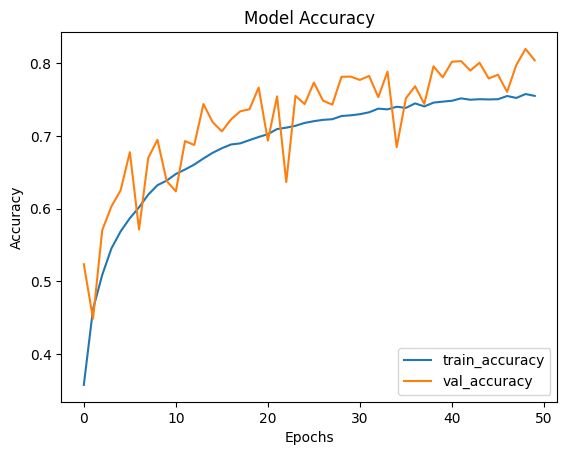

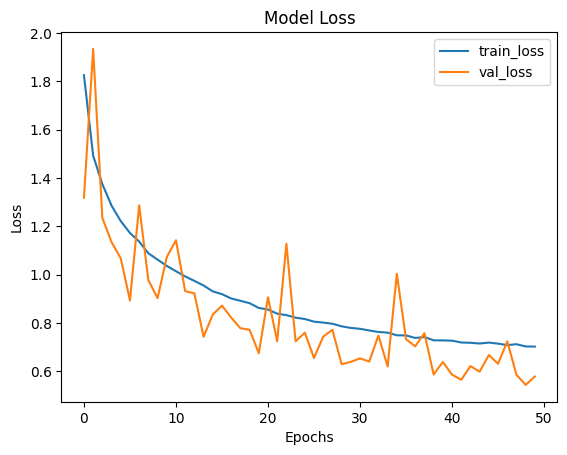

In [15]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    # Plot training & validation accuracy
    plt.plot(history.history['accuracy'], label='train_accuracy')
    plt.plot(history.history['val_accuracy'], label='val_accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.show()

    # Plot training & validation loss
    plt.plot(history.history['loss'], label='train_loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.title('Model Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.show()

# Plot the training history
plot_training_history(history)